# Exploratory Data Analysis — COVID-19 Brazil

# 1. Imports

In [ ]:
import pandas
import numpy
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# 2. Data Preparation

This notebook is self-contained: the cleaning pipeline is re-applied here rather than depending on `data_quality.ipynb` having been run first. This guarantees reproducibility — the EDA can be executed independently at any time.

## 2.1 Load Raw Data

CSV has no native null type. Values recorded as `"NA"`, `""`, or `"Importados/Indefinidos"` are read by pandas as plain strings — invisible to `isna()` and unaffected by interpolation. Replacing them with `numpy.nan` at load time makes them proper missing values from the start.

In [8]:
dataset = pandas.read_csv("data/caso_full.csv")

dataset = dataset.replace(
    ["<NA>", "NA", "NaN", "nan", "null", "", "Importados/Indefinidos"],
    numpy.nan
)

display(Markdown(f"**Rows loaded:** {len(dataset):,}"))

**Rows loaded:** 3,853,648

## 2.2 Cleaning Pipeline

Four decisions are applied in sequence. Order matters — each step depends on the previous one.

**`place_type == "state"`** — The dataset contains both city-level and state-level rows for the same dates. State rows already aggregate all cities within them, so keeping both granularities would double-count every case. Since the forecasting model operates at state level, the EDA must use the same granularity.

**`sort_values(["state", "date"])`** — Interpolation estimates missing values from neighboring rows. Those neighbors must be the chronologically adjacent days for the same state. Sorting by state then date guarantees this — without it, interpolation would draw from arbitrary rows.

**`where(~group["is_repeated"])`** — `is_repeated = True` means the secretariat published no bulletin that day, so `new_confirmed` is forced to `0` by convention — it does not mean zero new cases. The `where` call turns those zeros into `NaN`, making them eligible for interpolation. Keeping the `0` would teach the model that cases periodically vanish.

**`interpolate(method="linear")`** — Linear interpolation estimates each missing day from its neighbors. Linear is appropriate for daily data with short gaps (typically 1–2 days on weekends). Forward fill would reproduce the same zero-on-no-publication behavior being corrected; spline or polynomial would overfit single-day gaps.

**`.clip(lower=0)`** — Negative values arise when a secretariat reclassifies cases between municipalities. The model cannot learn from a negative case count. Clipping to zero is the least harmful treatment: it does not drop the row (which would create a gap) or interpolate (the value is known, just physically impossible).

In [9]:
df = dataset[
    dataset["place_type"] == "state"
].copy().sort_values(["state", "date"])

def clean_state_series(group):
    group = group.copy()
    group["new_confirmed"] = (
        group["new_confirmed"]
        .where(~group["is_repeated"])
        .interpolate(method="linear")
        .clip(lower=0)
    )
    return group

df = pandas.concat([
    clean_state_series(group)
    for _, group in df.groupby("state")
])

df["date"] = pandas.to_datetime(df["date"])

display(Markdown(f"**Records after cleaning:** {len(df):,}"))
display(Markdown(f"**Date range:** {df['date'].min().date()} → {df['date'].max().date()}"))
display(Markdown(f"**States:** {df['state'].nunique()}"))
df.head()

**Records after cleaning:** 20,119

**Date range:** 2020-02-25 → 2022-03-27

**States:** 27

,city,city_ibge_code,date,epidemiological_week,estimated_population,estimated_population_2019,is_last,is_repeated,last_available_confirmed,last_available_confirmed_per_100k_inhabitants,last_available_date,last_available_death_rate,last_available_deaths,order_for_place,place_type,state,new_confirmed,new_deaths
1,NaN,12.0,2020-03-17,202012,894470.0,881935.0,False,False,3,0.33539,2020-03-17,0.0,0,1,state,AC,3.0,0
3,NaN,12.0,2020-03-18,202012,894470.0,881935.0,False,False,3,0.33539,2020-03-18,0.0,0,2,state,AC,0.0,0
5,NaN,12.0,2020-03-19,202012,894470.0,881935.0,False,False,4,0.44719,2020-03-19,0.0,0,3,state,AC,1.0,0
7,NaN,12.0,2020-03-20,202012,894470.0,881935.0,False,False,7,0.78259,2020-03-20,0.0,0,4,state,AC,3.0,0
9,NaN,12.0,2020-03-21,202012,894470.0,881935.0,False,False,11,1.22978,2020-03-21,0.0,0,5,state,AC,4.0,0


# 3. National Time Series

Aggregates `new_confirmed` across all states to show the full arc of the pandemic in Brazil. The 7-day rolling average smooths out the weekly reporting noise (secretariats often publish fewer cases on weekends and catch up on Mondays), making the epidemic waves clearly visible.

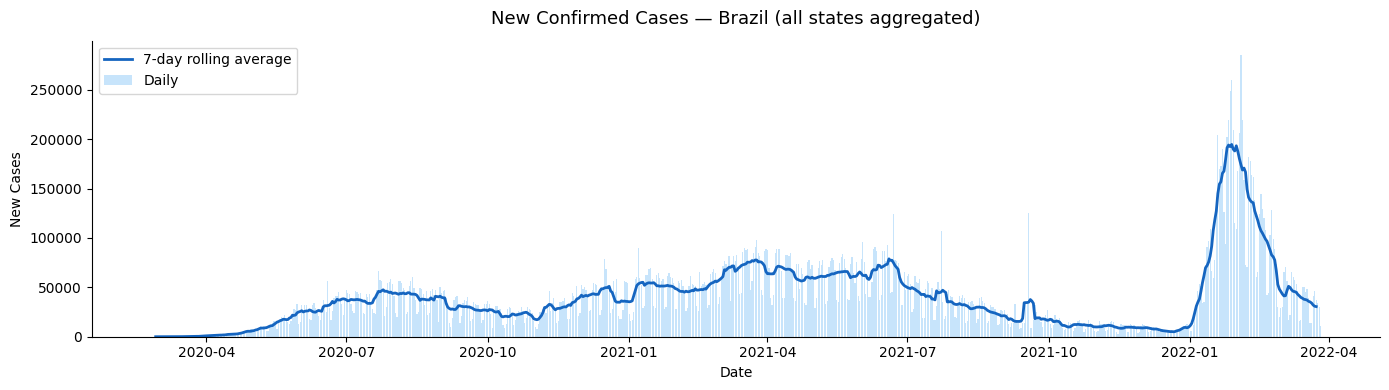

**Peak (daily):** 285,451 cases on 2022-02-03

In [10]:
national = (
    df.groupby("date")["new_confirmed"]
    .sum()
    .sort_index()
)

rolling_7d = national.rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(national.index, national.values, color="#90caf9", alpha=0.5, label="Daily")
ax.plot(national.index, rolling_7d, color="#1565c0", lw=2, label="7-day rolling average")

ax.set_title("New Confirmed Cases — Brazil (all states aggregated)", fontsize=13, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("New Cases")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

display(Markdown(f"**Peak (daily):** {national.max():,.0f} cases on {national.idxmax().date()}"))

# 4. State Comparison

Small multiples for the 9 states with the highest total case counts. Each subplot uses an independent y-axis (`sharey=False`) because absolute volumes differ by orders of magnitude between SP and smaller states — a shared axis would flatten every series except São Paulo.

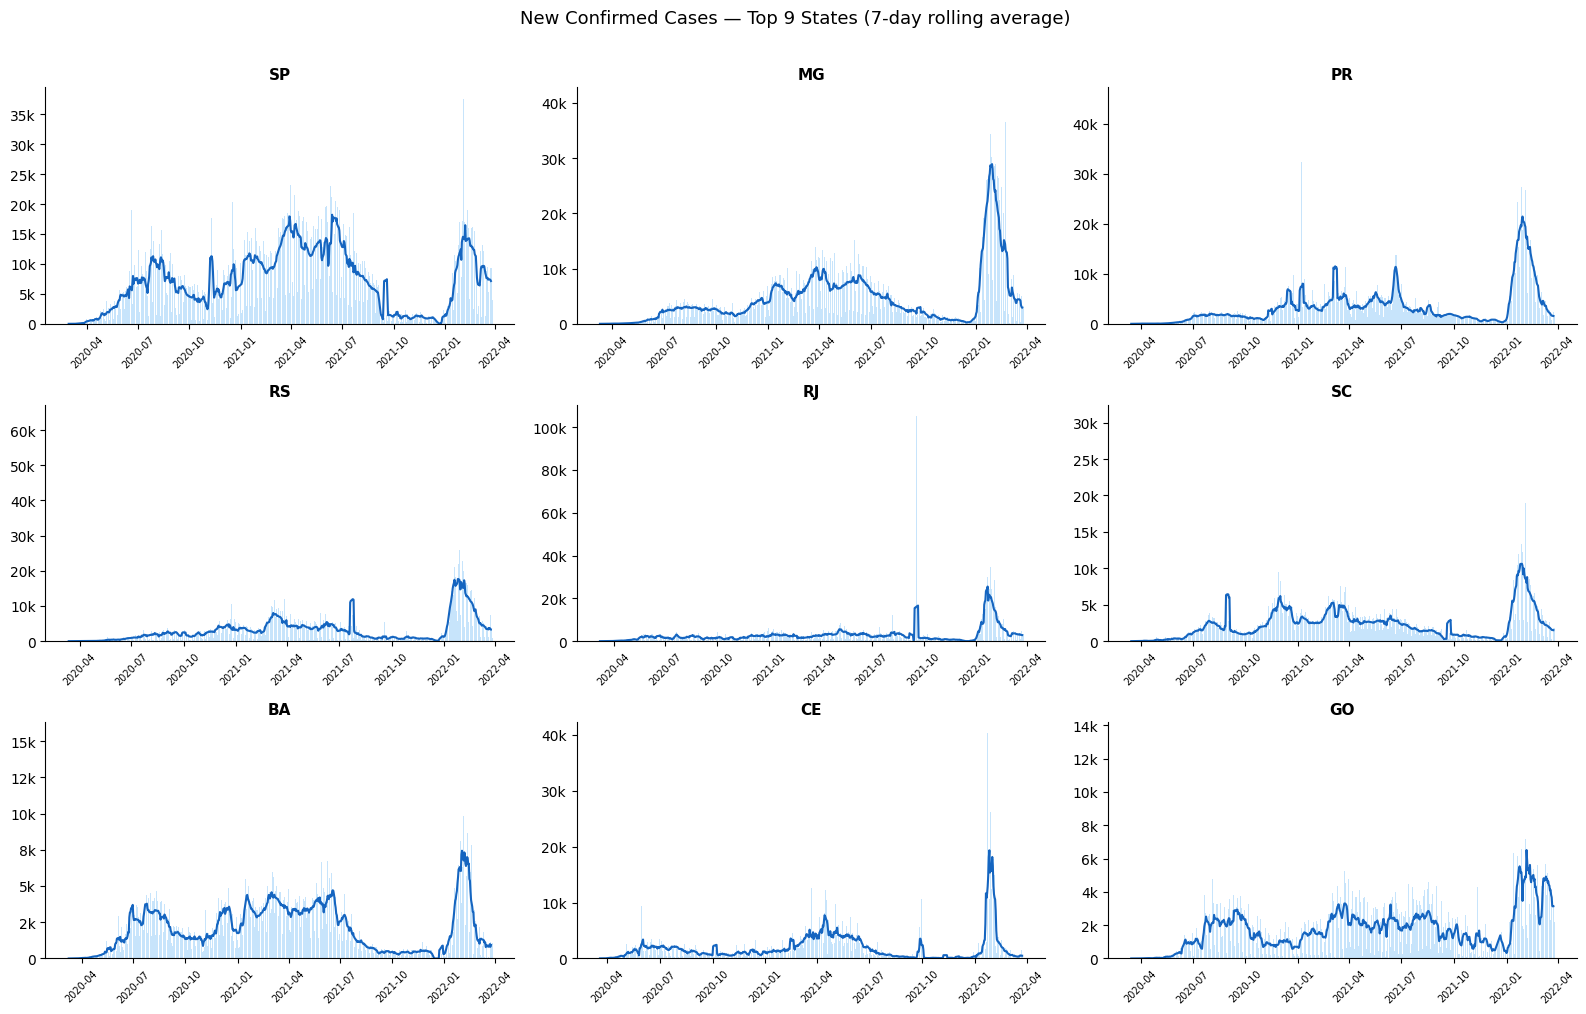

In [11]:
top_states = (
    df.groupby("state")["new_confirmed"]
    .sum()
    .nlargest(9)
    .index.tolist()
)

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=False)

for ax, state in zip(axes.flat, top_states):
    s = df[df["state"] == state].set_index("date")["new_confirmed"]
    ax.bar(s.index, s.values, color="#90caf9", alpha=0.5)
    ax.plot(s.index, s.rolling(7, center=True).mean(), color="#1565c0", lw=1.5)
    ax.set_title(state, fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1_000:.0f}k" if x >= 1000 else str(int(x)))
    )
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("New Confirmed Cases — Top 9 States (7-day rolling average)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4.1 Regional Comparison: Nordeste vs Sudeste

Aggregates cases by region to compare epidemic dynamics. The two regions have different population sizes, so the series are normalized per 100k inhabitants to make the comparison fair — otherwise Sudeste would dominate purely due to scale.

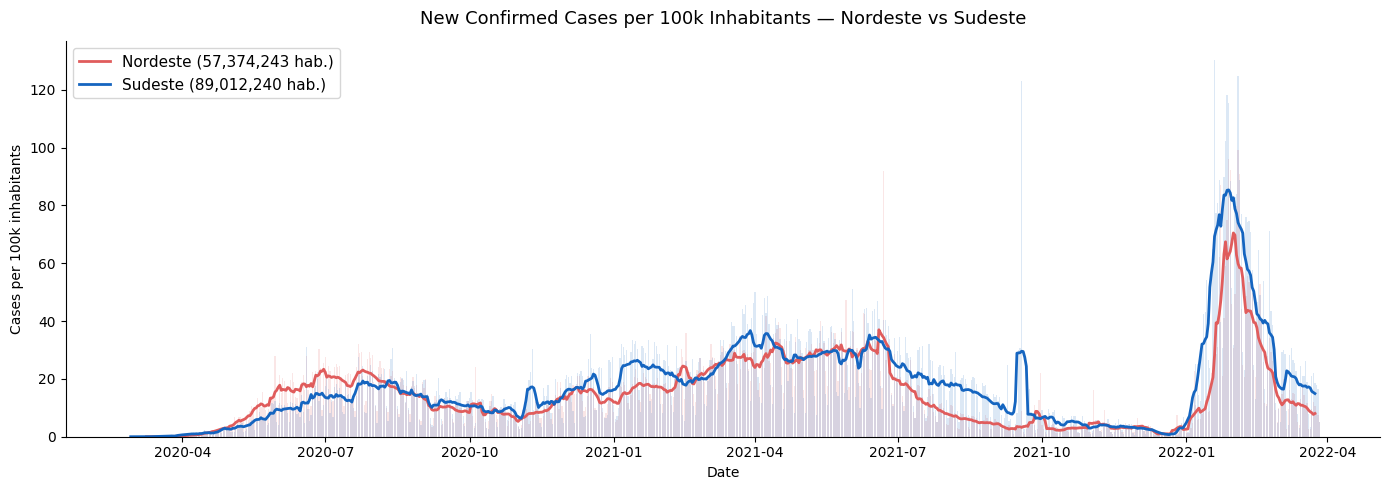

**Nordeste peak:** 99.3 cases/100k on 2022-02-03

**Sudeste peak:** 130.5 cases/100k on 2022-01-19

In [ ]:
NORDESTE = ["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"]
SUDESTE  = ["ES", "MG", "RJ", "SP"]

pop_per_state = (
    df.sort_values("date")
    .groupby("state")["estimated_population"]
    .last()
)

region_pop = {
    "Nordeste": pop_per_state[pop_per_state.index.isin(NORDESTE)].sum(),
    "Sudeste":  pop_per_state[pop_per_state.index.isin(SUDESTE)].sum(),
}

region_series = {}
for label, states in [("Nordeste", NORDESTE), ("Sudeste", SUDESTE)]:
    total = (
        df[df["state"].isin(states)]
        .groupby("date")["new_confirmed"]
        .sum()
        .sort_index()
    )
    region_series[label] = total / region_pop[label] * 100_000

colors = {"Nordeste": "#e05c5c", "Sudeste": "#1565c0"}

fig, ax = plt.subplots(figsize=(14, 5))

for label, series in region_series.items():
    ax.bar(series.index, series.values, color=colors[label], alpha=0.15)
    ax.plot(series.index, series.rolling(7, center=True).mean(),
            color=colors[label], lw=2, label=f"{label} ({region_pop[label]:,.0f} hab.)")

ax.set_title("New Confirmed Cases per 100k Inhabitants — Nordeste vs Sudeste", fontsize=13, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Cases per 100k inhabitants")
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

for label, series in region_series.items():
    peak_val  = series.max()
    peak_date = series.idxmax().date()
    display(Markdown(f"**{label} peak:** {peak_val:.1f} cases/100k on {peak_date}"))
